In [1]:
from SWChannel_numba_jitclass import SWchannel_numba_jitclass
import numpy as np
import matplotlib.pyplot as plt

In [2]:
s=SWchannel_numba_jitclass()

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
Cannot resolve setattr: (instance.jitclass.SWchannel_numba_jitclass#7f12204c5370<>).nx = int64

File "SWChannel_numba_jitclass.py", line 20:
    def __init__(self,
        <source elided>
        
        self.nx=nx
        ^

During: typing of set attribute 'nx' at /home/rfajber/code/SW_FD/SWChannel_numba_jitclass.py (20)

File "SWChannel_numba_jitclass.py", line 20:
    def __init__(self,
        <source elided>
        
        self.nx=nx
        ^

During: Pass nopython_type_inference
During: resolving callee type: jitclass.SWchannel_numba_jitclass#7f12204c5370<>
During: typing of call at <string> (3)

During: resolving callee type: jitclass.SWchannel_numba_jitclass#7f12204c5370<>
During: typing of call at <string> (3)


File "<string>", line 3:
<source missing, REPL/exec in use?>

During: Pass nopython_type_inference

In [43]:
s.hi = s.H0
s.ui = 10*np.cosh( (s.y2-np.mean(s.y2))/5e5 )**(-2)
s.vi = np.zeros(np.shape(s.y2))

s.vi += 1e-1*np.cos(12*np.pi*s.x2/(s.dx*s.nx))*np.sin(2*np.pi*s.y2/(s.dy*s.ny))#np.random.randn(s.ny,s.nx)
s.ui += 1e-1*np.sin(-12*np.pi*s.x2/(s.dx*s.nx))*np.cos(2*np.pi*s.y2/(s.dy*s.ny))#np.random.randn(s.ny,s.nx)

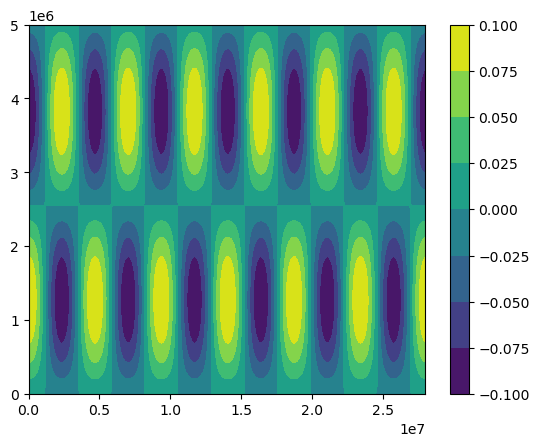

In [45]:
plt.contourf(s.xc,
             s.yc,
             s.vi)
plt.colorbar()

In [61]:
s.dt=60
s.nt=24*5*60
s.expInitialized=True
s.HB = np.zeros([s.ny,s.nx])
s.hb = np.ones(s.nx)*s.H0
s.ht = np.ones(s.nx)*s.H0
s.runExperiment()

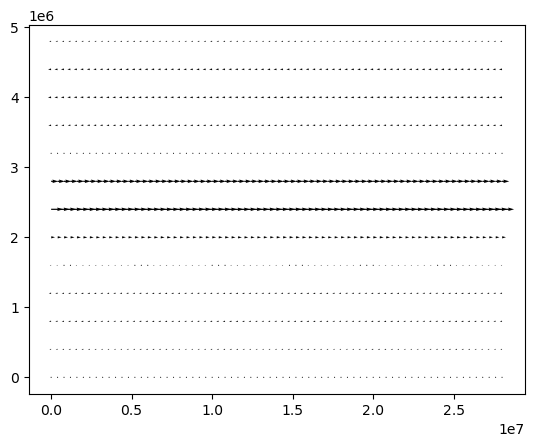

In [67]:
it = 500
nplt = 4
plt.quiver(s.xc[::nplt],s.yc[::nplt],
           s.u[it,::nplt,::nplt],s.v[it,::nplt,::nplt],
           scale_units='xy',
           scale=1e-5
           )

In [70]:
from numba.experimental import jitclass